In [1]:
# Importer les librairies
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score #Cette métrique est utilisé pour calculer la fiabilité et la performance de notre modèle

In [5]:
#Importer le dataset
# Le dataset contient les écarts de température entre les années 1880 et 2018
dataset = pd.read_excel('datas/Data_Temp.xlsx')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

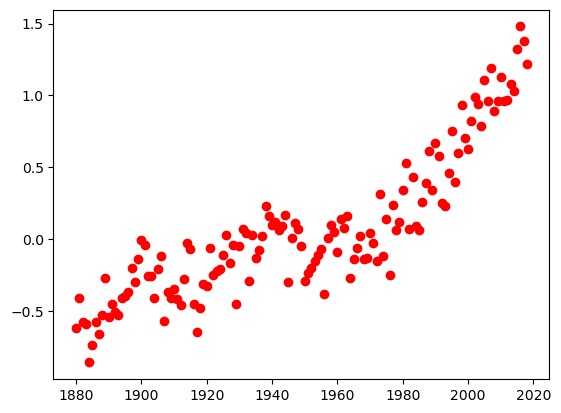

In [6]:
#Représenter le dataset sous forme d'un nuage de point
plt.scatter(X, y, color = 'red')

In [7]:
#Créer et entrainer un modèle régression linéaire simple
regressor = LinearRegression()
regressor.fit(X, y)
y_pred = regressor.predict(X) #Prédire les valeurs de Y sachant que ici on n'a pas scindé les données de train et de test

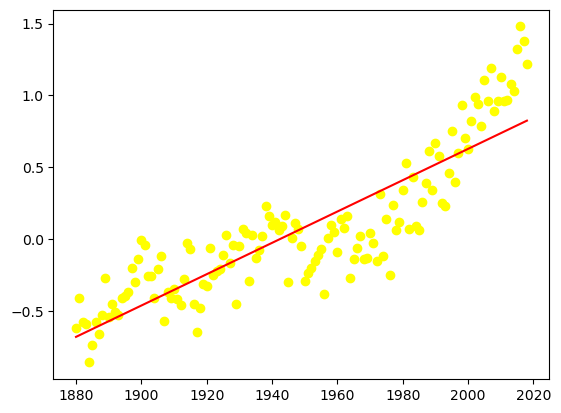

In [9]:
# Visulaiser le résultat
plt.scatter(X, y, color='yellow') #Tracer le nuage de point 
plt.plot(X, regressor.predict(X), color='red' ) # Tracer la droite; X c'est les  variables explicatives et je veux prédire en utilisant .predict(X)

# On remarque que le taux d'erre sera élevé

In [14]:
#Calculer la performance (et fiabilité )du modèle avec r2_score
# Plus le r2_score est proche de 1 plus le modèle est performant
r2 = r2_score(y, y_pred)
r2

0.7555302976418108

In [18]:
#Créer et entrainer un modèle de regression polynomiale
poly_regression = PolynomialFeatures(degree=3) #On instancie la classe PolyPolynomialFeatures  avec degré =3

# on va "fit_transform" = "entrainer et tranformer" les deonnées de X pour  Avoir les données de X sous form polynomiale
X_poly = poly_regression.fit_transform(X)

regressor_poly = LinearRegression() #On écare une régression linéaire simple
# On donne à la régression linéaire les données à fiter (entrainer) X_poly et Y
regressor_poly.fit(X_poly, y)
y_poly_pred = regressor_poly.predict(X_poly)

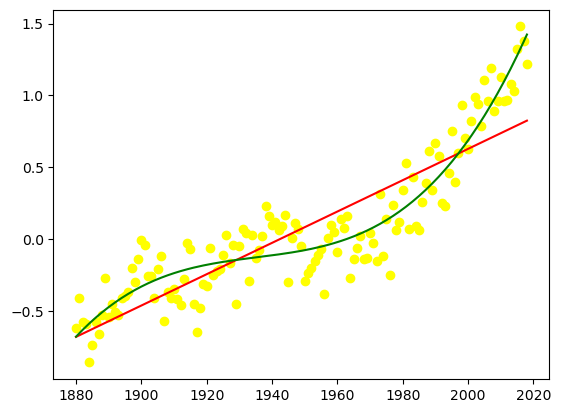

In [20]:
#Visualiser les résultats
plt.scatter(X, y, color='yellow') #Tracer le nuage de point 
plt.plot(X, regressor.predict(X), color='red' ) # Droite concernat la régression Linéaire
plt.plot(X, regressor_poly.predict(X_poly), color='green' ) # Droite concernat la régression polynomiale

In [21]:
r2 = r2_score(y, y_poly_pred)
r2

0.8847459380302541

In [ ]:
# Faire une nouvelle prédiction par exemple pour l'année 2030
predictions = poly_regression.fit_transform